특성 공학과 규제

In [114]:
import pandas as pd

#csv파일 로드
perch_full = pd.read_csv('https://bit.ly/perch_csv_data')
#처음 다섯 행 출력
perch_full.head()

,length,height,width
0,8.4,2.11,1.41
1,13.7,3.53,2.00
2,15.0,3.82,2.43
3,16.2,4.59,2.63
4,17.4,4.59,2.94


타깃 데이터(무게)

In [115]:
import numpy as np

perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])
from sklearn.model_selection import train_test_split

#훈련 세트와 테스트 세트로 나누기
train_input, test_input, train_target, test_target = train_test_split(perch_full, perch_weight, random_state=42)

#다항 특성 만들기
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures()
poly.fit([[2,3]])

print(poly.transform([[2,3]])) #fit을 한 후 transform 사용 가능
# 1(bias), 2, 3, 2^2, 2*3, 3^2 



[[1. 2. 3. 4. 6. 9.]]


절편은 추가하지 않도록 하여 변환

In [116]:
poly = PolynomialFeatures(include_bias=False)
poly.fit(train_input)
train_poly = poly.transform(train_input)
print(train_poly.shape)

(42, 9)


In [117]:
poly.get_feature_names_out()

array(['length', ' height', ' width', 'length^2', 'length  height',
       'length  width', ' height^2', ' height  width', ' width^2'],
      dtype=object)

총 9개의 특성이 만들어짐

In [118]:
test_poly = poly.transform(test_input) #훈련세트를 기준으로 테스트 세트를 변환

fit() 은 데이터를 통해 규칙을 찾아내는 것이고 transform은 찾아낸 규칙대로 데이터를 바꾸는 것이므로
test의 경우에는 fit을 하지 않음

In [119]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(train_poly, train_target)
print(lr.score(train_poly,train_target))
print(lr.score(test_poly, test_target))

0.9903183436982126
0.9714559911594125


더 많은 특성 만들기

In [120]:
poly = PolynomialFeatures(degree=5, include_bias=False) #5승까지 특성을 만듦

poly.fit(train_input)
train_poly = poly.transform(train_input)
test_poly = poly.transform(test_input)

print(train_poly.shape)

lr.fit(train_poly, train_target)

print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

(42, 55)
0.9999999999997232
-144.40564483377855


모델이 너무 과하게 훈련데이터를 훈련하지 않도록 규제(linearregression의 경우에는 스케일에 큰 영향을 받지 않으므로 사용하지 않았음)

In [121]:
from sklearn.preprocessing import StandardScaler #특성 마다 차이가 크지 않도록 스케일을 맞춤

ss = StandardScaler()
ss.fit(train_poly) #훈련데이터의 평균과 표준편차로 테스트세트를 변환

train_scaled = ss.transform(train_poly)
test_scaled = ss.transform(test_poly)

릿지 회귀 - 가중치의 제곱을 벌칙으로 사용하여 큰 가중치를 작게 만듦

In [122]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(train_scaled, train_target)

print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9896101671037343
0.9790693977615387


적절한 규제 강도 찾기

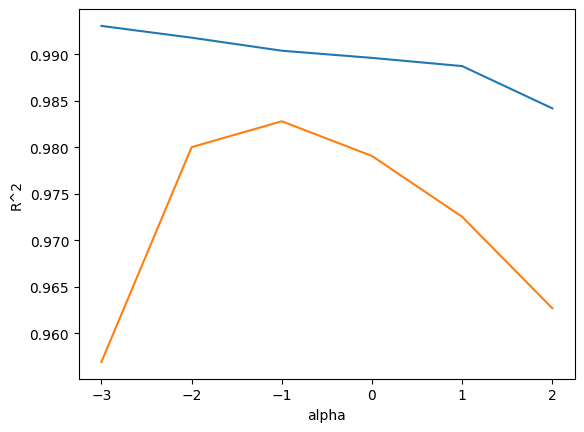

In [123]:
import matplotlib.pyplot as plot
train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    ridge = Ridge(alpha=alpha)
    ridge.fit(train_scaled, train_target)
    train_score.append(ridge.score(train_scaled, train_target))
    test_score.append(ridge.score(test_scaled, test_target))

plot.plot(np.log10(alpha_list), train_score)
plot.plot(np.log10(alpha_list), test_score)
plot.xlabel('alpha')
plot.ylabel('R^2')
plot.show()

- 파란 선: 훈련세트
- 노란 선: 테스트세트
- 그래프의 왼쪽의 경우 과대적합, 오른쪽의 경우 과소적합
- -1에서 두 그래프가 가장 가까움

In [124]:
ridge = Ridge(alpha=0.1)
ridge.fit(train_scaled, train_target)

print(ridge.score(train_scaled, train_target))
print(ridge.score(test_scaled, test_target))

0.9903815817570367
0.9827976465386928


라쏘 회귀 - 가중치의 절대값을 벌칙으로 사용

In [125]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.989789897208096
0.9800593698421884


c:\Users\78960\dl\ml_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.336e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\78960\dl\ml_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.025e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\78960\dl\ml_env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.062e+02, toleranc

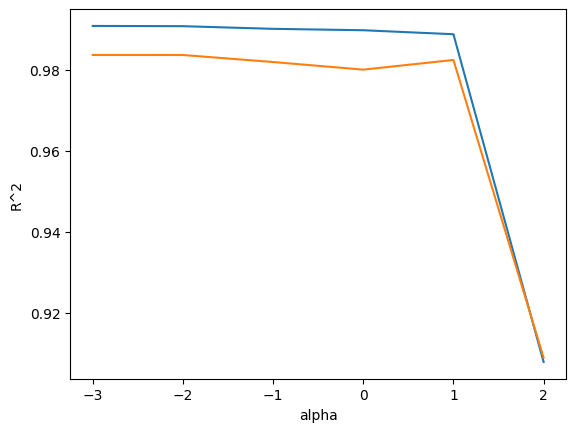

In [126]:
train_score = []
test_score = []
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    lasso = Lasso(alpha=alpha)
    lasso.fit(train_scaled, train_target)
    train_score.append(lasso.score(train_scaled, train_target))
    test_score.append(lasso.score(test_scaled, test_target))

plot.plot(np.log10(alpha_list), train_score)
plot.plot(np.log10(alpha_list), test_score)
plot.xlabel('alpha')
plot.ylabel('R^2')
plot.show()

alpha가 10인 경우 두 그래프가 최적

In [ ]:
lasso = Lasso(alpha=10)
lasso.fit(train_scaled, train_target)

print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

print(np.sum(lasso.coef_==0))   #55개 중 40개가 필요없는 특성

0.9888067471131866
0.9824470598706695
40
